In [110]:
import pandas as pd

df = pd.read_csv("bayut_all_locations_transactions.csv")

In [111]:
df.head()
df.info()
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 135421 entries, 0 to 135420
Data columns (total 15 columns):
 #   Column                      Non-Null Count   Dtype
---  ------                      --------------   -----
 0   main_location               135421 non-null  str  
 1   sub_location                134473 non-null  str  
 2   building_project            48784 non-null   str  
 3   location_selected           135421 non-null  str  
 4   date                        135421 non-null  str  
 5   category                    135421 non-null  str  
 6   sub-category                135421 non-null  str  
 7   location_image              135421 non-null  str  
 8   is_off_plan?                135421 non-null  bool 
 9   price(EAD)                  135421 non-null  str  
 10  is_Vacant_at_time_of_sale?  135421 non-null  bool 
 11  type                        135421 non-null  str  
 12  beds                        135288 non-null  str  
 13  built_up(sqft)              135421 non-null  str  
 14 

(135421, 15)

In [112]:
df = df.drop(columns=['location_selected','category', 'sub-category', 'location_image'])

In [113]:
df['date'] = pd.to_datetime(df['date'])

In [114]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['quarter'] = df['date'].dt.quarter

In [115]:
df.columns

Index(['main_location', 'sub_location', 'building_project', 'date',
       'is_off_plan?', 'price(EAD)', 'is_Vacant_at_time_of_sale?', 'type',
       'beds', 'built_up(sqft)', 'plot(sqft)', 'year', 'month', 'quarter'],
      dtype='str')

In [116]:
df['price(EAD)'] = df['price(EAD)'].astype(str).str.replace(',', '')
df['price(EAD)'] = df['price(EAD)'].astype(float)

df['built_up(sqft)'] = df['built_up(sqft)'].astype(str).str.replace(',', '')
df['built_up(sqft)'] = pd.to_numeric(df['built_up(sqft)'], errors='coerce')

df['plot(sqft)'] = df['plot(sqft)'].astype(str).str.replace(',', '')
df['plot(sqft)'] = pd.to_numeric(df['plot(sqft)'], errors='coerce')

In [117]:
df.isnull().sum()

main_location                      0
sub_location                     948
building_project               86637
date                               0
is_off_plan?                       0
price(EAD)                         0
is_Vacant_at_time_of_sale?         0
type                               0
beds                             133
built_up(sqft)                   153
plot(sqft)                    123286
year                               0
month                              0
quarter                            0
dtype: int64

In [118]:
df.shape

(135421, 14)

In [119]:
rows_to_remove = df[df['built_up(sqft)'].isna() & df['plot(sqft)'].isna()]

removed_rows = rows_to_remove.copy()

df.drop(rows_to_remove.index, inplace=True)

In [120]:
df.shape

(135385, 14)

In [121]:
df.isna().sum()

main_location                      0
sub_location                     948
building_project               86601
date                               0
is_off_plan?                       0
price(EAD)                         0
is_Vacant_at_time_of_sale?         0
type                               0
beds                             133
built_up(sqft)                   117
plot(sqft)                    123250
year                               0
month                              0
quarter                            0
dtype: int64

In [123]:
# built_up(sqft)
df.loc[
    (df['type'] == 'Residential Plot') & (df['built_up(sqft)'].isna()),
    'built_up(sqft)'
] = 0

# building_project
df['building_project'] = df['building_project'].fillna(df['sub_location'])

# plot(sqft)
df.loc[
    (df['type'] == 'Apartment') & (df['plot(sqft)'].isna()),
    'plot(sqft)'
] = 0

In [124]:
# plot(sqft)
df.loc[
    (df['type'] == 'Hotel Apartment') & (df['plot(sqft)'].isna()),
    'plot(sqft)'
] = 0

In [125]:
# plot(sqft)
df.loc[
    (df['type'] == 'Penthouse') & (df['plot(sqft)'].isna()),
    'plot(sqft)'
] = 0

In [127]:
# Identify rows where BOTH sub_location and building_project are NA
mask = df['sub_location'].isna() & df['building_project'].isna()

# Fill those NA values with the corresponding main_location
df.loc[mask, 'sub_location'] = df.loc[mask, 'main_location']
df.loc[mask, 'building_project'] = df.loc[mask, 'main_location']

# Verify the fix
print(f"Filled {mask.sum()} rows where both sub_location and building_project were NA.")
print("\nRemaining NA counts:")
print(df[['sub_location', 'building_project']].isna().sum())


Filled 948 rows where both sub_location and building_project were NA.

Remaining NA counts:
sub_location        0
building_project    0
dtype: int64


In [128]:
df.isna().sum()

main_location                   0
sub_location                    0
building_project                0
date                            0
is_off_plan?                    0
price(EAD)                      0
is_Vacant_at_time_of_sale?      0
type                            0
beds                          133
built_up(sqft)                 80
plot(sqft)                      0
year                            0
month                           0
quarter                         0
dtype: int64

In [130]:
# plot(sqft)
df.loc[
    (df['type'] == 'Residential Plot') & (df['beds'].isna()),
    'beds'
] = 0

TypeError: Invalid value '0' for dtype 'str'. Value should be a string or missing value, got 'int' instead.

In [134]:
df['beds'].value_counts()

beds
1         55867
Studio    32419
2         29008
3          9219
4          6181
5          2230
6           277
7            50
8             1
Name: count, dtype: int64

In [133]:
df[df['beds'].isna()]

,main_location,sub_location,building_project,date,is_off_plan?,price(EAD),is_Vacant_at_time_of_sale?,type,beds,built_up(sqft),plot(sqft),year,month,quarter
7833,Jumeirah Village Circle (JVC),JVC District 13,IR1DIAN Park,2025-03-25,False,22500000.0,True,Residential Plot,NaN,0.0,26697.0,2025,3,1
8291,Jumeirah Village Circle (JVC),JVC District 13,Parkwood Villas 1,2025-10-15,False,23695280.0,True,Residential Plot,NaN,0.0,25981.0,2025,10,4
16837,Jumeirah Village Circle (JVC),JVC District 16,District 16J,2025-10-10,False,4700000.0,True,Residential Plot,NaN,0.0,6839.0,2025,10,4
16840,Jumeirah Village Circle (JVC),JVC District 16,District 16C,2025-08-29,False,4350000.0,True,Residential Plot,NaN,0.0,7890.0,2025,8,3
16842,Jumeirah Village Circle (JVC),JVC District 16,District 16E,2025-10-30,False,4400000.0,True,Residential Plot,NaN,0.0,7846.0,2025,10,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131322,Dubailand,The Palmarosa,The Palmarosa,2025-11-14,True,2000000.0,False,Villa,NaN,NaN,3700.0,2025,11,4
131323,Dubailand,The Palmarosa,The Palmarosa,2025-09-15,True,4138574.0,False,Villa,NaN,NaN,3195.0,2025,9,3
131324,Dubailand,The Palmarosa,The Palmarosa,2025-05-22,True,3910000.0,False,Villa,NaN,592.0,6330.0,2025,5,2
133676,Al Wasl,City Walk,Central Park Plaza,2025-08-26,True,7450000.0,False,Apartment,NaN,2235.0,0.0,2025,8,3


In [96]:
# Filter and display rows where sub_location is null
df_sub_na = df[df['sub_location'].isna()]

print(f"Total rows with missing sub-location: {len(df_sub_na)}")

df_sub_na['main_location'].value_counts()

Total rows with missing sub-location: 0


Series([], Name: count, dtype: int64)

In [101]:
df.isna().sum()

main_location                  0
sub_location                   0
building_project               0
date                           0
is_off_plan?                   0
price(EAD)                     0
is_Vacant_at_time_of_sale?     0
type                           0
beds                          78
built_up(sqft)                 0
plot(sqft)                     0
year                           0
month                          0
quarter                        0
dtype: int64

In [102]:
df[df['beds'].isna()]['main_location'].value_counts()

main_location
Dubai South                        28
Dubai Hills Estate                 20
Jumeirah Village Circle (JVC)       5
Dubai Maritime City                 5
Dubai Land Residence Complex        3
Business Bay                        2
Jumeirah Village Triangle (JVT)     2
Majan                               2
Arjan                               2
Dubai Sports City                   2
Dubailand                           2
Al Wasl                             2
Dubai Marina                        1
Downtown Dubai                      1
International City                  1
Name: count, dtype: int64

In [86]:
# import pandas as pd
# from IPython.display import display

# # This will temporarily show all rows for just this output
# with pd.option_context('display.max_rows', None):
#     display(df[df['built_up(sqft)'].isnull()])

# # Set globally
# pd.set_option('display.max_rows', None)

# # Now it will print all rows
# df[df['built_up(sqft)'].isnull()]



In [107]:
df

,main_location,sub_location,building_project,date,is_off_plan?,price(EAD),is_Vacant_at_time_of_sale?,type,built_up(sqft),plot(sqft),year,month,quarter,price_per_sqft,lag1,lag3,lag6,roll3,roll6
6,14,11 Hills Park,11 Hills Park,2025-03-18,1,827888.0,0,0,501.0,0.0,2025,3,1,1652.471058,1379.540041,1366.911392,1538.110883,1578.300142,1490.785093
7,14,11 Hills Park,11 Hills Park,2025-03-18,1,727629.0,0,0,487.0,0.0,2025,3,1,1494.104723,1652.471058,1702.889328,1365.890526,1508.705274,1512.154126
8,14,11 Hills Park,11 Hills Park,2025-03-18,1,1408724.0,0,0,824.0,0.0,2025,3,1,1709.616505,1494.104723,1379.540041,1477.008214,1618.730762,1550.922175
9,14,11 Hills Park,11 Hills Park,2025-03-19,1,1242872.0,0,0,824.0,0.0,2025,3,1,1508.339806,1709.616505,1652.471058,1366.911392,1570.687011,1574.493577
10,14,11 Hills Park,11 Hills Park,2025-03-19,1,1351578.0,0,0,824.0,0.0,2025,3,1,1640.264563,1508.339806,1494.104723,1702.889328,1619.406958,1564.056116
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115448,27,Zahra Breeze Apartments,Zahra Breeze Apartments,2026-02-20,0,840000.0,0,0,639.0,0.0,2026,2,1,1314.553991,1198.801199,1191.536748,1054.644809,1107.006200,1193.917612
115449,27,Zahra Breeze Apartments,Zahra Breeze Apartments,2026-02-27,0,810000.0,0,0,603.0,0.0,2026,2,1,1343.283582,1314.553991,807.663411,1408.934708,1285.546257,1182.975757
115450,27,Zahra Breeze Apartments,Zahra Breeze Apartments,2026-03-05,0,1150000.0,1,0,940.0,0.0,2026,3,1,1223.404255,1343.283582,1198.801199,1242.015614,1293.747276,1179.873864
115451,27,Zahra Breeze Apartments,Zahra Breeze Apartments,2026-03-07,0,1480000.0,0,0,1555.0,0.0,2026,3,1,951.768489,1223.404255,1314.553991,1191.536748,1172.818775,1139.912488


In [87]:
df['type'].unique()

<StringArray>
['Apartment', 'Villa', 'Hotel Apartment', 'Penthouse', 'Residential Plot']
Length: 5, dtype: str

In [100]:
rows_to_remove = df[df['built_up(sqft)'].isna()]

removed_rows = pd.concat([removed_rows, rows_to_remove], ignore_index=True)

df.drop(rows_to_remove.index, inplace=True)

In [103]:
df['is_off_plan?'] = df['is_off_plan?'].astype(int)
df['is_Vacant_at_time_of_sale?'] = df['is_Vacant_at_time_of_sale?'].astype(int)

In [89]:
df.shape

(135385, 14)

In [22]:
import numpy as np

df['price_per_sqft'] = np.where(
    df['type'] == 'Residential Plot',
    df['price(EAD)'] / df['plot(sqft)'],
    df['price(EAD)'] / df['built_up(sqft)']
)

In [108]:
df.isna().sum()

main_location                 0
sub_location                  0
building_project              0
date                          0
is_off_plan?                  0
price(EAD)                    0
is_Vacant_at_time_of_sale?    0
type                          0
built_up(sqft)                0
plot(sqft)                    0
year                          0
month                         0
quarter                       0
price_per_sqft                0
lag1                          0
lag3                          0
lag6                          0
roll3                         0
roll6                         0
dtype: int64

In [23]:
df.to_csv("final_data.csv", index=False)

In [24]:
import pandas as pd
import os

# Define file paths
input_file = '/home/paramesh/Documents/sellanyhome-ai/sellanyhome/eda/final_data.csv'
output_above_60 = '/home/paramesh/Documents/sellanyhome-ai/sellanyhome/eda/final_data_above_60.csv'
output_below_60 = '/home/paramesh/Documents/sellanyhome-ai/sellanyhome/eda/final_data_below_60.csv'

def split_data(input_path, above_path, below_path):
    print(f"Reading {input_path}...")
    df = pd.read_csv(input_path)
    
    # Count rows per sub_location
    sub_location_counts = df['sub_location'].value_counts()
    
    # Identify sub_locations with more than 60 rows
    sub_locations_above_60 = sub_location_counts[sub_location_counts >=60].index
    
    # Split the dataframe
    df_above_60 = df[df['sub_location'].isin(sub_locations_above_60)]
    df_below_60 = df[~df['sub_location'].isin(sub_locations_above_60)]
    
    # Save to CSV
    print(f"Saving rows with sub_location count >=60 to {above_path}...")
    df_above_60.to_csv(above_path, index=False)
    
    print(f"Saving rows with sub_location count < 60 to {below_path}...")
    df_below_60.to_csv(below_path, index=False)
    
    print("Done!")
    print(f"Rows in above 60: {len(df_above_60)}")
    print(f"Rows in below or equal 60: {len(df_below_60)}")

if __name__ == "__main__":
    split_data(input_file, output_above_60, output_below_60)


Reading /home/paramesh/Documents/sellanyhome-ai/sellanyhome/eda/final_data.csv...
Saving rows with sub_location count >=60 to /home/paramesh/Documents/sellanyhome-ai/sellanyhome/eda/final_data_above_60.csv...
Saving rows with sub_location count < 60 to /home/paramesh/Documents/sellanyhome-ai/sellanyhome/eda/final_data_below_60.csv...
Done!
Rows in above 60: 115527
Rows in below or equal 60: 19778


In [25]:
import pandas as pd

# Define file paths
input_file = '/home/paramesh/Documents/sellanyhome-ai/sellanyhome/eda/final_data.csv'
output_above_60 = '/home/paramesh/Documents/sellanyhome-ai/sellanyhome/eda/final_data_above_60.csv'
output_below_60 = '/home/paramesh/Documents/sellanyhome-ai/sellanyhome/eda/final_data_below_60.csv'

def split_data(input_path, above_path, below_path):
    print(f"Reading {input_path}...")
    df = pd.read_csv(input_path)
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values(['sub_location', 'date'])

    # Count rows per sub_location
    sub_location_counts = df['sub_location'].value_counts()

    # Identify sub_locations with 60 or more rows
    sub_locations_above_60 = set(sub_location_counts[sub_location_counts >= 60].index)

    # Now simulate the XGBoost training logic to find problematic sub-locations
    # (lag features + dropna + date split)
    temp_df = df[df['sub_location'].isin(sub_locations_above_60)].copy()
    temp_df['lag1'] = temp_df.groupby('sub_location')['price_per_sqft'].shift(1)
    temp_df['lag3'] = temp_df.groupby('sub_location')['price_per_sqft'].shift(3)
    temp_df['lag6'] = temp_df.groupby('sub_location')['price_per_sqft'].shift(6)
    temp_df['roll3'] = temp_df.groupby('sub_location')['price_per_sqft'].transform(lambda x: x.rolling(3).mean())
    temp_df['roll6'] = temp_df.groupby('sub_location')['price_per_sqft'].transform(lambda x: x.rolling(6).mean())
    temp_df = temp_df.dropna()

    skipped_subs = set()
    for sub, sub_df in temp_df.groupby('sub_location'):
        if len(sub_df) < 10:
            skipped_subs.add(sub)
            continue
        split_date = sub_df['date'].quantile(0.8)
        train_data = sub_df[sub_df['date'] <= split_date]
        test_data = sub_df[sub_df['date'] > split_date]
        if len(train_data) < 8 or len(test_data) < 2:
            skipped_subs.add(sub)

    if skipped_subs:
        print(f"\nMoving {len(skipped_subs)} sub-location(s) to below_60 (would be skipped during training):")
        for s in skipped_subs:
            print(f"  - {s}")
        sub_locations_above_60 -= skipped_subs

    # Final split on the ORIGINAL dataframe (no feature engineering)
    df_above_60 = df[df['sub_location'].isin(sub_locations_above_60)]
    df_below_60 = df[~df['sub_location'].isin(sub_locations_above_60)]

    # Save to CSV (drop the date parsing, save original format)
    print(f"\nSaving {len(df_above_60)} rows ({len(sub_locations_above_60)} sub-locations) to {above_path}...")
    df_above_60.to_csv(above_path, index=False)

    below_count = len(sub_location_counts) - len(sub_locations_above_60)
    print(f"Saving {len(df_below_60)} rows ({below_count} sub-locations) to {below_path}...")
    df_below_60.to_csv(below_path, index=False)

    print("\nDone!")

if __name__ == "__main__":
    split_data(input_file, output_above_60, output_below_60)


Reading /home/paramesh/Documents/sellanyhome-ai/sellanyhome/eda/final_data.csv...

Moving 1 sub-location(s) to below_60 (would be skipped during training):
  - Falcon Tower

Saving 115453 rows (411 sub-locations) to /home/paramesh/Documents/sellanyhome-ai/sellanyhome/eda/final_data_above_60.csv...
Saving 19852 rows (755 sub-locations) to /home/paramesh/Documents/sellanyhome-ai/sellanyhome/eda/final_data_below_60.csv...

Done!


In [26]:
df['date'] = pd.to_datetime(df['date'])

df_loc = df.groupby(
    ['sub_location', pd.Grouper(key='date', freq='ME')]
)['price(EAD)'].mean().reset_index()

Train size: (90794, 15)
Test size: (22193, 15)
MAE (price_per_sqft): 121.78174098116976
MAE (price AED): 127140.11706935147


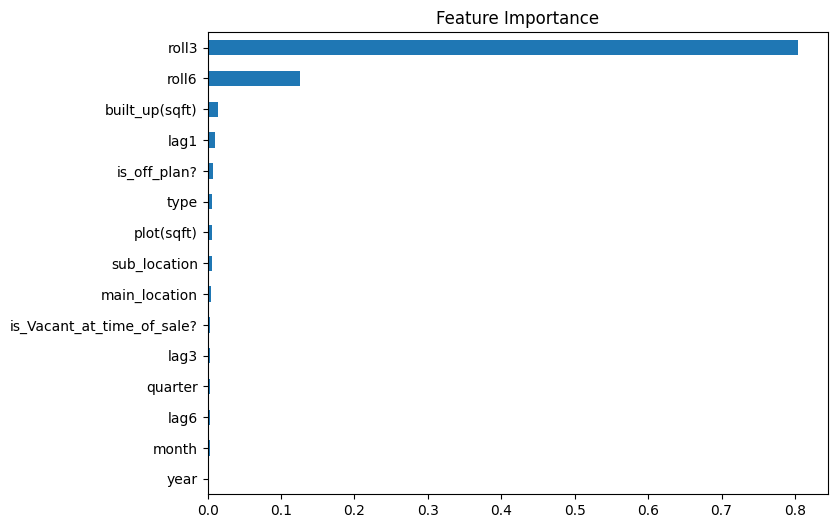

In [27]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error
from xgboost import XGBRegressor


df = pd.read_csv("final_data_above_60.csv")


df['date'] = pd.to_datetime(df['date'])

df = df.sort_values(['sub_location','date'])


df['lag1'] = df.groupby('sub_location')['price_per_sqft'].shift(1)
df['lag3'] = df.groupby('sub_location')['price_per_sqft'].shift(3)
df['lag6'] = df.groupby('sub_location')['price_per_sqft'].shift(6)


df['roll3'] = df.groupby('sub_location')['price_per_sqft'].transform(
    lambda x: x.rolling(3).mean()
)

df['roll6'] = df.groupby('sub_location')['price_per_sqft'].transform(
    lambda x: x.rolling(6).mean()
)


df = df.dropna()


cat_cols = ['main_location','sub_location','type']

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

features = [
    'main_location',
    'sub_location',
    'type',
    'built_up(sqft)',
    'plot(sqft)',
    'is_off_plan?',
    'is_Vacant_at_time_of_sale?',
    'year',
    'month',
    'quarter',
    'lag1',
    'lag3',
    'lag6',
    'roll3',
    'roll6'
]

target = 'price_per_sqft'


split_date = df['date'].quantile(0.8)

train = df[df['date'] <= split_date]
test = df[df['date'] > split_date]

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


model = XGBRegressor(
    n_estimators=400,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8
)

model.fit(X_train, y_train)


pred = model.predict(X_test)


mae = mean_absolute_error(y_test, pred)

print("MAE (price_per_sqft):", mae)

predicted_price = pred * X_test['built_up(sqft)']

actual_price = test['price(EAD)']

price_mae = mean_absolute_error(actual_price, predicted_price)

print("MAE (price AED):", price_mae)

import matplotlib.pyplot as plt

importance = model.feature_importances_

feat_importance = pd.Series(importance, index=features)

feat_importance.sort_values().plot(kind='barh', figsize=(8,6))
plt.title("Feature Importance")
plt.show()

In [28]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display, clear_output
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from xgboost import XGBRegressor
import warnings

warnings.filterwarnings('ignore')

# 1. Load and Preprocess Data
print("Loading data...")
df = pd.read_csv("final_data_above_60.csv")

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['sub_location', 'date'])

# Feature Engineering
df['lag1'] = df.groupby('sub_location')['price_per_sqft'].shift(1)
df['lag3'] = df.groupby('sub_location')['price_per_sqft'].shift(3)
df['lag6'] = df.groupby('sub_location')['price_per_sqft'].shift(6)

df['roll3'] = df.groupby('sub_location')['price_per_sqft'].transform(lambda x: x.rolling(3).mean())
df['roll6'] = df.groupby('sub_location')['price_per_sqft'].transform(lambda x: x.rolling(6).mean())

df = df.dropna()

# Encode categorical variables
for col in ['main_location', 'type']:
    df[col] = LabelEncoder().fit_transform(df[col])

features = [
    'type', 'built_up(sqft)', 'plot(sqft)',
    'is_off_plan?', 'is_Vacant_at_time_of_sale?',
    'year', 'month', 'quarter',
    'lag1', 'lag3', 'lag6', 'roll3', 'roll6'
]

target = 'price_per_sqft'

# 2. Train Per Sub-Location Models
sub_locations = sorted(df['sub_location'].unique())
model_results = {}

print(f"Training {len(sub_locations)} sub-location models...")

progress = widgets.IntProgress(
    value=0,
    min=0,
    max=len(sub_locations),
    description='Training:',
    bar_style='info'
)

display(progress)

grouped = df.groupby('sub_location')

for sub, sub_df in grouped:

    sub_df = sub_df.copy()

    if len(sub_df) < 10:
        progress.value += 1
        continue

    split_date = sub_df['date'].quantile(0.8)

    train_data = sub_df[sub_df['date'] <= split_date].copy()
    test_data = sub_df[sub_df['date'] > split_date].copy()

    if len(train_data) < 8 or len(test_data) < 2:
        progress.value += 1
        continue

    # XGBoost GPU Model
    model = XGBRegressor(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method="hist",
        device="cuda",
        random_state=42
    )

    model.fit(train_data[features], train_data[target])

    train_data.loc[:, 'pred'] = model.predict(train_data[features])
    test_data.loc[:, 'pred'] = model.predict(test_data[features])

    metrics = {
        'train_mae': mean_absolute_error(train_data[target], train_data['pred']),
        'train_rmse': np.sqrt(mean_squared_error(train_data[target], train_data['pred'])),
        'test_mae': mean_absolute_error(test_data[target], test_data['pred']),
        'test_rmse': np.sqrt(mean_squared_error(test_data[target], test_data['pred'])),
        'test_r2': r2_score(test_data[target], test_data['pred'])
    }

    model_results[sub] = {
        'train': train_data,
        'test': test_data,
        'metrics': metrics
    }

    progress.value += 1

progress.close()

print(f"Successfully trained {len(model_results)} models.")

# 3. Interactive Dashboard

output = widgets.Output()

def update_dashboard(sub_name):

    with output:

        clear_output(wait=True)

        res = model_results[sub_name]

        train_res = res['train']
        test_res = res['test']
        m = res['metrics']

        def to_monthly(d):

            return d.groupby(d['date'].dt.to_period('M')).agg({
                'date': 'first',
                target: 'mean',
                'pred': 'mean'
            }).reset_index(drop=True)

        train_m = to_monthly(train_res)
        test_m = to_monthly(test_res)

        display(widgets.HTML(f"""
        <div style="display: flex; gap: 12px; font-family: sans-serif; padding: 10px; background: #f1f3f5; border-radius: 12px; margin-bottom: 25px;">

            <div style="flex:1;padding:15px;background:white;border-radius:10px;text-align:center;">
                <h4 style="margin:0;color:#6c757d;font-size:11px;">Train MAE</h4>
                <p style="font-size:22px;font-weight:700;color:#4361EE;">{m['train_mae']:,.1f}</p>
            </div>

            <div style="flex:1;padding:15px;background:white;border-radius:10px;text-align:center;">
                <h4 style="margin:0;color:#6c757d;font-size:11px;">Train RMSE</h4>
                <p style="font-size:22px;font-weight:700;color:#7209B7;">{m['train_rmse']:,.1f}</p>
            </div>

            <div style="flex:1;padding:15px;background:white;border-radius:10px;text-align:center;">
                <h4 style="margin:0;color:#6c757d;font-size:11px;">Test MAE</h4>
                <p style="font-size:22px;font-weight:700;color:#F77F00;">{m['test_mae']:,.1f}</p>
            </div>

            <div style="flex:1;padding:15px;background:white;border-radius:10px;text-align:center;">
                <h4 style="margin:0;color:#6c757d;font-size:11px;">Test RMSE</h4>
                <p style="font-size:22px;font-weight:700;color:#E63946;">{m['test_rmse']:,.1f}</p>
            </div>

            <div style="flex:1;padding:15px;background:white;border-radius:10px;text-align:center;">
                <h4 style="margin:0;color:#6c757d;font-size:11px;">Test R²</h4>
                <p style="font-size:22px;font-weight:700;color:#2ECC71;">{m['test_r2']:.3f}</p>
            </div>

        </div>
        """))

        fig = go.Figure()

        fig.add_trace(go.Scatter(
            x=train_m['date'],
            y=train_m[target],
            name='Actual (Train)',
            line=dict(color='#4361EE', width=3)
        ))

        fig.add_trace(go.Scatter(
            x=test_m['date'],
            y=test_m[target],
            name='Actual (Test)',
            line=dict(color='#F77F00', width=3)
        ))

        fig.add_trace(go.Scatter(
            x=train_m['date'],
            y=train_m['pred'],
            name='Pred (Train)',
            line=dict(color='#A8DADC', width=2.5, dash='dot')
        ))

        fig.add_trace(go.Scatter(
            x=test_m['date'],
            y=test_m['pred'],
            name='Pred (Test)',
            line=dict(color='#E63946', width=2.5, dash='dot')
        ))

        fig.update_layout(
            title=f"Price per Sqft Trend: Actual vs Predicted - {sub_name}",
            xaxis_title="Date",
            yaxis_title="AED / Sqft",
            height=500,
            template='plotly_white',
            hovermode='x unified'
        )

        fig.show()

dropdown = widgets.Dropdown(
    options=sorted(model_results.keys()),
    description='Sub Location:',
    style={'description_width': 'initial'}
)

widgets.interactive(update_dashboard, sub_name=dropdown)

display(widgets.VBox([
    widgets.HTML("<h2 style='font-family:sans-serif;'>🏙️ Sub-Location Prediction Dashboard</h2>"),
    dropdown,
    output
]))

if model_results:
    update_dashboard(dropdown.value)

Loading data...
Training 411 sub-location models...


IntProgress(value=0, bar_style='info', description='Training:', max=411)

Successfully trained 411 models.


In [ ]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display, clear_output
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from xgboost import XGBRegressor
import warnings

warnings.filterwarnings('ignore')

# 1. Load and Preprocess Data
print("Loading data...")
df = pd.read_csv("final_data_above_60.csv")

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['sub_location', 'date'])

# Feature Engineering
df['lag1'] = df.groupby('sub_location')['price_per_sqft'].shift(1)
df['lag3'] = df.groupby('sub_location')['price_per_sqft'].shift(3)
df['lag6'] = df.groupby('sub_location')['price_per_sqft'].shift(6)

df['roll3'] = df.groupby('sub_location')['price_per_sqft'].transform(lambda x: x.rolling(3).mean())
df['roll6'] = df.groupby('sub_location')['price_per_sqft'].transform(lambda x: x.rolling(6).mean())

df = df.dropna()

# Encode categorical variables
for col in ['main_location', 'type']:
    df[col] = LabelEncoder().fit_transform(df[col])

features = [
    'type', 'built_up(sqft)', 'plot(sqft)',
    'is_off_plan?', 'is_Vacant_at_time_of_sale?',
    'year', 'month', 'quarter',
    'lag1', 'lag3', 'lag6', 'roll3', 'roll6'
]

target = 'price_per_sqft'

# 2. Train Per Sub-Location Models
sub_locations = sorted(df['sub_location'].unique())
model_results = {}

print(f"Training {len(sub_locations)} sub-location models...")

progress = widgets.IntProgress(
    value=0,
    min=0,
    max=len(sub_locations),
    description='Training:',
    bar_style='info'
)

display(progress)

grouped = df.groupby('sub_location')

for sub, sub_df in grouped:

    sub_df = sub_df.copy()

    if len(sub_df) < 10:
        progress.value += 1
        continue

    split_date = sub_df['date'].quantile(0.8)

    train_data = sub_df[sub_df['date'] <= split_date].copy()
    test_data = sub_df[sub_df['date'] > split_date].copy()

    if len(train_data) < 8 or len(test_data) < 2:
        progress.value += 1
        continue

    model = XGBRegressor(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method="hist",
        device="cuda",
        random_state=42
    )

    model.fit(train_data[features], train_data[target])

    train_data.loc[:, 'pred'] = model.predict(train_data[features])
    test_data.loc[:, 'pred'] = model.predict(test_data[features])

    metrics = {
        'train_mae': mean_absolute_error(train_data[target], train_data['pred']),
        'train_rmse': np.sqrt(mean_squared_error(train_data[target], train_data['pred'])),
        'test_mae': mean_absolute_error(test_data[target], test_data['pred']),
        'test_rmse': np.sqrt(mean_squared_error(test_data[target], test_data['pred'])),
        'test_r2': r2_score(test_data[target], test_data['pred'])
    }

    model_results[sub] = {
        'train': train_data,
        'test': test_data,
        'metrics': metrics
    }

    progress.value += 1

progress.close()

print(f"Successfully trained {len(model_results)} models.")

# 3. Interactive Dashboard

output = widgets.Output()

def update_dashboard(sub_name, freq):

    with output:

        clear_output(wait=True)

        res = model_results[sub_name]
        train_res = res['train']
        test_res = res['test']
        m = res['metrics']

        period = 'M' if freq == "Monthly" else 'W'

        def aggregate_data(d):
            return d.groupby(d['date'].dt.to_period(period)).agg({
                'date': 'first',
                target: 'mean',
                'pred': 'mean'
            }).reset_index(drop=True)

        train_m = aggregate_data(train_res)
        test_m = aggregate_data(test_res)

        display(widgets.HTML(f"""
        <div style="display: flex; gap: 12px; font-family: sans-serif; padding: 10px; background: #f1f3f5; border-radius: 12px; margin-bottom: 25px;">

            <div style="flex:1;padding:15px;background:white;border-radius:10px;text-align:center;">
                <h4 style="margin:0;color:#6c757d;font-size:11px;">Train MAE</h4>
                <p style="font-size:22px;font-weight:700;color:#4361EE;">{m['train_mae']:,.1f}</p>
            </div>

            <div style="flex:1;padding:15px;background:white;border-radius:10px;text-align:center;">
                <h4 style="margin:0;color:#6c757d;font-size:11px;">Train RMSE</h4>
                <p style="font-size:22px;font-weight:700;color:#7209B7;">{m['train_rmse']:,.1f}</p>
            </div>

            <div style="flex:1;padding:15px;background:white;border-radius:10px;text-align:center;">
                <h4 style="margin:0;color:#6c757d;font-size:11px;">Test MAE</h4>
                <p style="font-size:22px;font-weight:700;color:#F77F00;">{m['test_mae']:,.1f}</p>
            </div>

            <div style="flex:1;padding:15px;background:white;border-radius:10px;text-align:center;">
                <h4 style="margin:0;color:#6c757d;font-size:11px;">Test RMSE</h4>
                <p style="font-size:22px;font-weight:700;color:#E63946;">{m['test_rmse']:,.1f}</p>
            </div>

            <div style="flex:1;padding:15px;background:white;border-radius:10px;text-align:center;">
                <h4 style="margin:0;color:#6c757d;font-size:11px;">Test R²</h4>
                <p style="font-size:22px;font-weight:700;color:#2ECC71;">{m['test_r2']:.3f}</p>
            </div>

        </div>
        """))

        fig = go.Figure()

        fig.add_trace(go.Scatter(
            x=train_m['date'],
            y=train_m[target],
            name='Actual (Train)',
            line=dict(color='#4361EE', width=3)
        ))

        fig.add_trace(go.Scatter(
            x=test_m['date'],
            y=test_m[target],
            name='Actual (Test)',
            line=dict(color='#F77F00', width=3)
        ))

        fig.add_trace(go.Scatter(
            x=train_m['date'],
            y=train_m['pred'],
            name='Pred (Train)',
            line=dict(color='#A8DADC', width=2.5, dash='dot')
        ))

        fig.add_trace(go.Scatter(
            x=test_m['date'],
            y=test_m['pred'],
            name='Pred (Test)',
            line=dict(color='#E63946', width=2.5, dash='dot')
        ))

        fig.update_layout(
            title=f"Price per Sqft Trend ({freq}) - {sub_name}",
            xaxis_title="Date",
            yaxis_title="AED / Sqft",
            height=500,
            template='plotly_white',
            hovermode='x unified'
        )

        fig.show()

# Dropdowns
location_dropdown = widgets.Dropdown(
    options=sorted(model_results.keys()),
    description='Sub Location:',
    style={'description_width': 'initial'}
)

freq_dropdown = widgets.Dropdown(
    options=['Monthly', 'Weekly'],
    value='Monthly',
    description='View:',
    style={'description_width': 'initial'}
)

widgets.interactive(update_dashboard, sub_name=location_dropdown, freq=freq_dropdown)

display(widgets.VBox([
    widgets.HTML("<h2 style='font-family:sans-serif;'>🏙️ Sub-Location Prediction Dashboard</h2>"),
    widgets.HBox([location_dropdown, freq_dropdown]),
    output
]))

if model_results:
    update_dashboard(location_dropdown.value, freq_dropdown.value)

Loading data...
Training 411 sub-location models...


IntProgress(value=0, bar_style='info', description='Training:', max=411)

Successfully trained 411 models.


In [30]:
import joblib

# Save model
joblib.dump(model, "real_estate_price_model.pkl")

# Save encoder
joblib.dump(le, "location_encoder.pkl")

print("Model and encoder saved successfully.")

Model and encoder saved successfully.


In [40]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display, clear_output

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

import torch
import torch.nn as nn

import warnings
warnings.filterwarnings("ignore")

device = "cuda" if torch.cuda.is_available() else "cpu"

# -----------------------------
# 1 Load Data
# -----------------------------

print("Loading data...")

df = pd.read_csv("final_data_above_60.csv")

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["sub_location","date"])

# -----------------------------
# 2 Feature Engineering
# -----------------------------

df["lag1"] = df.groupby("sub_location")["price_per_sqft"].shift(1)
df["lag3"] = df.groupby("sub_location")["price_per_sqft"].shift(3)
df["lag6"] = df.groupby("sub_location")["price_per_sqft"].shift(6)

df["roll3"] = df.groupby("sub_location")["price_per_sqft"].transform(lambda x: x.rolling(3).mean())
df["roll6"] = df.groupby("sub_location")["price_per_sqft"].transform(lambda x: x.rolling(6).mean())

df = df.dropna().copy()

# Encoding

le_main = LabelEncoder()
le_type = LabelEncoder()

df["main_location"] = le_main.fit_transform(df["main_location"])
df["type"] = le_type.fit_transform(df["type"])

features = [
"type","built_up(sqft)","plot(sqft)",
"is_off_plan?","is_Vacant_at_time_of_sale?",
"year","month","quarter",
"lag1","lag3","lag6","roll3","roll6"
]

target = "price_per_sqft"

# -----------------------------
# 3 LSTM Model
# -----------------------------

class LSTMModel(nn.Module):

    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(1,64,batch_first=True)
        self.fc = nn.Linear(64,1)

    def forward(self,x):
        out,_ = self.lstm(x)
        out = self.fc(out[:,-1,:])
        return out


def create_sequences(series,seq_len=6):

    X=[]
    y=[]

    for i in range(len(series)-seq_len):
        X.append(series[i:i+seq_len])
        y.append(series[i+seq_len])

    return np.array(X),np.array(y)

# -----------------------------
# 4 Train Models
# -----------------------------

model_results = {}

print("Training models...")

for sub, sub_df in df.groupby("sub_location"):

    sub_df = sub_df.copy()

    if len(sub_df) < 20:
        continue

    split_date = sub_df["date"].quantile(0.8)

    train_data = sub_df[sub_df["date"] <= split_date].copy()
    test_data = sub_df[sub_df["date"] > split_date].copy()

    if len(test_data) < 3:
        continue

    # -----------------------------
    # XGBOOST MODEL
    # -----------------------------

    xgb_model = XGBRegressor(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method="hist",
        random_state=42
    )

    xgb_model.fit(train_data[features],train_data[target])

    train_data["xgb_pred"] = xgb_model.predict(train_data[features])
    test_data["xgb_pred"] = xgb_model.predict(test_data[features])

    # -----------------------------
    # LSTM MODEL
    # -----------------------------

    scaler = MinMaxScaler()

    series = scaler.fit_transform(sub_df[[target]]).flatten()

    X,y = create_sequences(series,6)

    split = int(len(X)*0.8)

    X_train = X[:split]
    X_test = X[split:]

    y_train = y[:split]
    y_test = y[split:]

    X_train_tensor = torch.tensor(X_train).float().unsqueeze(-1).to(device)
    y_train_tensor = torch.tensor(y_train).float().to(device)

    model = LSTMModel().to(device)

    optimizer = torch.optim.Adam(model.parameters(),lr=0.001)
    loss_fn = nn.MSELoss()

    for epoch in range(30):

        optimizer.zero_grad()

        pred = model(X_train_tensor).squeeze()

        loss = loss_fn(pred,y_train_tensor)

        loss.backward()

        optimizer.step()

    with torch.no_grad():

        X_tensor = torch.tensor(X).float().unsqueeze(-1).to(device)

        preds = model(X_tensor).cpu().numpy().flatten()

    preds = scaler.inverse_transform(preds.reshape(-1,1)).flatten()

    sub_df = sub_df.iloc[6:].copy()

    sub_df["lstm_pred"] = preds

    train_lstm = sub_df.iloc[:split].copy()
    test_lstm = sub_df.iloc[split:].copy()

    # -----------------------------
    # Metrics
    # -----------------------------

    metrics = {

        "xgb_mae":mean_absolute_error(test_data[target],test_data["xgb_pred"]),
        "xgb_rmse":np.sqrt(mean_squared_error(test_data[target],test_data["xgb_pred"])),
        "xgb_r2":r2_score(test_data[target],test_data["xgb_pred"]),

        "lstm_mae":mean_absolute_error(test_lstm[target],test_lstm["lstm_pred"]),
        "lstm_rmse":np.sqrt(mean_squared_error(test_lstm[target],test_lstm["lstm_pred"])),
        "lstm_r2":r2_score(test_lstm[target],test_lstm["lstm_pred"])
    }

    print(f"{sub} | XGB MAE: {metrics['xgb_mae']:.2f} | LSTM MAE: {metrics['lstm_mae']:.2f}")

    model_results[sub] = {

        "train_xgb":train_data,
        "test_xgb":test_data,
        "train_lstm":train_lstm,
        "test_lstm":test_lstm,
        "metrics":metrics
    }

print("Training complete.")

# -----------------------------
# 5 Dashboard
# -----------------------------

output = widgets.Output()

def update_dashboard(sub_name,freq,model_type):

    with output:

        clear_output(wait=True)

        if model_type=="xgb":

            train = model_results[sub_name]["train_xgb"].copy()
            test = model_results[sub_name]["test_xgb"].copy()
            pred_col="xgb_pred"

        else:

            train = model_results[sub_name]["train_lstm"].copy()
            test = model_results[sub_name]["test_lstm"].copy()
            pred_col="lstm_pred"

        metrics = model_results[sub_name]["metrics"]

        period = "M" if freq=="Monthly" else "W"

        train["period"] = train["date"].dt.to_period(period)
        test["period"] = test["date"].dt.to_period(period)

        train_plot = train.groupby("period").agg({
            "date":"first",
            target:"mean",
            pred_col:"mean"
        }).reset_index(drop=True)

        test_plot = test.groupby("period").agg({
            "date":"first",
            target:"mean",
            pred_col:"mean"
        }).reset_index(drop=True)

        fig = go.Figure()

        fig.add_trace(go.Scatter(
        x=train_plot["date"],
        y=train_plot[target],
        name="Actual (Train)"
        ))

        fig.add_trace(go.Scatter(
        x=train_plot["date"],
        y=train_plot[pred_col],
        name="Pred (Train)",
        line=dict(dash="dot")
        ))

        fig.add_trace(go.Scatter(
        x=test_plot["date"],
        y=test_plot[target],
        name="Actual (Test)"
        ))

        fig.add_trace(go.Scatter(
        x=test_plot["date"],
        y=test_plot[pred_col],
        name="Pred (Test)",
        line=dict(dash="dot")
        ))

        fig.update_layout(
        title=f"{sub_name} Price Prediction ({model_type.upper()})",
        xaxis_title="Date",
        yaxis_title="Price per Sqft",
        template="plotly_white",
        height=500
        )

        display(widgets.HTML(f"""
        <b>XGB Test MAE:</b> {metrics['xgb_mae']:.2f} |
        <b>LSTM Test MAE:</b> {metrics['lstm_mae']:.2f}
        """))

        fig.show()

# -----------------------------
# Widgets
# -----------------------------

location_dropdown = widgets.Dropdown(
options=list(model_results.keys()),
description="Location"
)

freq_dropdown = widgets.Dropdown(
options=["Weekly","Monthly"],
value="Weekly",
description="View"
)

model_dropdown = widgets.Dropdown(
options=["xgb","lstm"],
value="xgb",
description="Model"
)

widgets.interactive(update_dashboard,
sub_name=location_dropdown,
freq=freq_dropdown,
model_type=model_dropdown)

display(widgets.VBox([
widgets.HTML("<h2>Price Prediction Dashboard</h2>"),
widgets.HBox([location_dropdown,freq_dropdown,model_dropdown]),
output
]))

update_dashboard(location_dropdown.value,freq_dropdown.value,model_dropdown.value)

Loading data...
Training models...
11 Hills Park | XGB MAE: 59.12 | LSTM MAE: 74.78
15 Cascade | XGB MAE: 55.57 | LSTM MAE: 265.97
29 Boulevard | XGB MAE: 327.94 | LSTM MAE: 491.81
A 99 | XGB MAE: 65.14 | LSTM MAE: 81.85
AG AUM Residence | XGB MAE: 188.15 | LSTM MAE: 220.36
AG Ark Tower | XGB MAE: 16.24 | LSTM MAE: 47.07
Address Dubai Mall | XGB MAE: 509.23 | LSTM MAE: 1114.45
Address Grand Downtown | XGB MAE: 271.17 | LSTM MAE: 537.50
Address Harbour Point | XGB MAE: 285.29 | LSTM MAE: 450.75
Aeternitas Tower | XGB MAE: 158.42 | LSTM MAE: 320.83
Al Furjan West | XGB MAE: 171.37 | LSTM MAE: 235.86
Al Habtoor City | XGB MAE: 198.97 | LSTM MAE: 375.01
Al Habtoor Polo Resort and Club - The Residences | XGB MAE: 106.39 | LSTM MAE: 101.65
Al Majara | XGB MAE: 210.78 | LSTM MAE: 679.57
Al Rabia Tower | XGB MAE: 24.17 | LSTM MAE: 42.69
Albero by Emaar | XGB MAE: 53.93 | LSTM MAE: 177.45
Altan | XGB MAE: 72.90 | LSTM MAE: 233.81
Altia One | XGB MAE: 41.11 | LSTM MAE: 50.51
Alton | XGB MAE: 142

In [46]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display, clear_output

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import mean_absolute_error

from xgboost import XGBRegressor
from statsmodels.tsa.arima.model import ARIMA

import torch
import torch.nn as nn

import warnings
warnings.filterwarnings("ignore")

# -------------------------------------------------
# GPU Setup
# -------------------------------------------------

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# -------------------------------------------------
# Load Data
# -------------------------------------------------

df = pd.read_csv("final_data_above_60.csv")

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["sub_location","date"])

# -------------------------------------------------
# Feature Engineering
# -------------------------------------------------

df["lag1"] = df.groupby("sub_location")["price_per_sqft"].shift(1)
df["lag3"] = df.groupby("sub_location")["price_per_sqft"].shift(3)
df["lag6"] = df.groupby("sub_location")["price_per_sqft"].shift(6)

df["roll3"] = df.groupby("sub_location")["price_per_sqft"].transform(lambda x: x.rolling(3).mean())
df["roll6"] = df.groupby("sub_location")["price_per_sqft"].transform(lambda x: x.rolling(6).mean())

df = df.dropna().copy()

# -------------------------------------------------
# Encoding
# -------------------------------------------------

le_main = LabelEncoder()
le_type = LabelEncoder()

df["main_location"] = le_main.fit_transform(df["main_location"])
df["type"] = le_type.fit_transform(df["type"])

features = [
"type","built_up(sqft)","plot(sqft)",
"is_off_plan?","is_Vacant_at_time_of_sale?",
"year","month","quarter",
"lag1","lag3","lag6","roll3","roll6"
]

target = "price_per_sqft"

# -------------------------------------------------
# Multivariate LSTM Model
# -------------------------------------------------

class LSTMModel(nn.Module):

    def __init__(self,input_size):

        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=128,
            num_layers=3,
            dropout=0.2,
            batch_first=True
        )

        self.fc1 = nn.Linear(128,64)
        self.fc2 = nn.Linear(64,32)
        self.fc3 = nn.Linear(32,1)

        self.relu = nn.ReLU()

    def forward(self,x):

        out,_ = self.lstm(x)

        out = out[:,-1,:]

        out = self.relu(self.fc1(out))
        out = self.relu(self.fc2(out))

        out = self.fc3(out)

        return out


def create_sequences(data,seq_len=6):

    X=[]
    y=[]

    for i in range(len(data)-seq_len):

        X.append(data[i:i+seq_len,:-1])
        y.append(data[i+seq_len,-1])

    return np.array(X),np.array(y)

# -------------------------------------------------
# Train Models
# -------------------------------------------------

model_results={}

for sub,sub_df in df.groupby("sub_location"):

    sub_df=sub_df.copy()

    if len(sub_df)<25:
        continue

    split_date=sub_df["date"].quantile(0.8)

    train=sub_df[sub_df["date"]<=split_date].copy()
    test=sub_df[sub_df["date"]>split_date].copy()

    if len(test)<3:
        continue

    # -------------------------------------------------
    # XGBoost
    # -------------------------------------------------

    xgb=XGBRegressor(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method="hist",
        device=device
    )

    xgb.fit(train[features],train[target])

    train["xgb_pred"]=xgb.predict(train[features])
    test["xgb_pred"]=xgb.predict(test[features])

    # -------------------------------------------------
    # Multivariate LSTM
    # -------------------------------------------------

    lstm_features=features+[target]

    scaler=MinMaxScaler()

    scaled_data=scaler.fit_transform(sub_df[lstm_features])

    X,y=create_sequences(scaled_data,6)

    split=int(len(X)*0.8)

    X_train=X[:split]
    y_train=y[:split]

    X_tensor=torch.tensor(X_train).float().to(device)
    y_tensor=torch.tensor(y_train).float().to(device)

    model=LSTMModel(input_size=len(features)).to(device)

    optimizer=torch.optim.Adam(model.parameters(),lr=0.001)
    loss_fn=nn.MSELoss()

    for epoch in range(40):

        optimizer.zero_grad()

        pred=model(X_tensor).squeeze()

        loss=loss_fn(pred,y_tensor)

        loss.backward()

        optimizer.step()

    with torch.no_grad():

        X_all=torch.tensor(X).float().to(device)

        preds=model(X_all).cpu().numpy().flatten()

    preds_full=np.zeros((len(preds),len(lstm_features)))
    preds_full[:,-1]=preds

    preds=scaler.inverse_transform(preds_full)[:,-1]

    lstm_df=sub_df.iloc[6:].copy()
    lstm_df["lstm_pred"]=preds

    train_lstm=lstm_df[lstm_df["date"]<=split_date].copy()
    test_lstm=lstm_df[lstm_df["date"]>split_date].copy()

    # -------------------------------------------------
    # ARIMA
    # -------------------------------------------------

    arima_model=ARIMA(train[target],order=(5,1,0)).fit()

    train["arima_pred"]=arima_model.predict(
        start=train.index[0],
        end=train.index[-1]
    )

    arima_pred=arima_model.forecast(steps=len(test))

    test["arima_pred"]=arima_pred.values

    # -------------------------------------------------
    # Metrics
    # -------------------------------------------------

    metrics={

        "xgb_mae":mean_absolute_error(test[target],test["xgb_pred"]),
        "lstm_mae":mean_absolute_error(test_lstm[target],test_lstm["lstm_pred"]),
        "arima_mae":mean_absolute_error(test[target],test["arima_pred"])
    }

    model_results[sub]={

        "train":train,
        "test":test,
        "train_lstm":train_lstm,
        "test_lstm":test_lstm,
        "metrics":metrics
    }

# -------------------------------------------------
# Dashboard
# -------------------------------------------------

output=widgets.Output()

def update_dashboard(sub_name,freq,model_type):

    with output:

        clear_output(wait=True)

        data=model_results[sub_name]

        if model_type=="xgb":

            train=data["train"].copy()
            test=data["test"].copy()
            pred="xgb_pred"

        elif model_type=="lstm":

            train=data["train_lstm"].copy()
            test=data["test_lstm"].copy()
            pred="lstm_pred"

        else:

            train=data["train"].copy()
            test=data["test"].copy()
            pred="arima_pred"

        metrics=data["metrics"]

        period="M" if freq=="Monthly" else "W"

        train["period"]=train["date"].dt.to_period(period)
        test["period"]=test["date"].dt.to_period(period)

        train_plot=train.groupby("period").agg({
            "date":"first",
            target:"mean",
            pred:"mean"
        }).reset_index(drop=True)

        test_plot=test.groupby("period").agg({
            "date":"first",
            target:"mean",
            pred:"mean"
        }).reset_index(drop=True)

        fig=go.Figure()

        fig.add_trace(go.Scatter(
            x=train_plot["date"],
            y=train_plot[target],
            name="Actual Train"
        ))

        fig.add_trace(go.Scatter(
            x=train_plot["date"],
            y=train_plot[pred],
            name="Pred Train",
            line=dict(dash="dot")
        ))

        fig.add_trace(go.Scatter(
            x=test_plot["date"],
            y=test_plot[target],
            name="Actual Test"
        ))

        fig.add_trace(go.Scatter(
            x=test_plot["date"],
            y=test_plot[pred],
            name="Pred Test",
            line=dict(dash="dot")
        ))

        fig.update_layout(
            title=f"{sub_name} Price Prediction ({model_type.upper()})",
            template="plotly_white",
            height=500
        )

        display(widgets.HTML(f"""
        <div style="display:flex;gap:40px;margin-bottom:20px">

        <div>
        <b>XGB MAE</b><br>{metrics['xgb_mae']:.2f}
        </div>

        <div>
        <b>LSTM MAE</b><br>{metrics['lstm_mae']:.2f}
        </div>

        <div>
        <b>ARIMA MAE</b><br>{metrics['arima_mae']:.2f}
        </div>

        </div>
        """))

        fig.show()

# -------------------------------------------------
# Widgets
# -------------------------------------------------

location_dropdown=widgets.Dropdown(
options=list(model_results.keys()),
description="Location"
)

freq_dropdown=widgets.Dropdown(
options=["Weekly","Monthly"],
value="Weekly",
description="View"
)

model_dropdown=widgets.Dropdown(
options=["xgb","lstm","arima"],
value="xgb",
description="Model"
)

widgets.interactive(update_dashboard,
sub_name=location_dropdown,
freq=freq_dropdown,
model_type=model_dropdown)

display(widgets.VBox([
widgets.HTML("<h2>Price Prediction Dashboard</h2>"),
widgets.HBox([location_dropdown,freq_dropdown,model_dropdown]),
output
]))

update_dashboard(location_dropdown.value,freq_dropdown.value,model_dropdown.value)

Using device: cuda


In [48]:
import pandas as pd

importance = xgb.feature_importances_

importance_df = pd.DataFrame({
    "feature": features,
    "importance": importance
}).sort_values("importance", ascending=False)

print("\nXGBoost Feature Importance")
print(importance_df)


XGBoost Feature Importance
                       feature  importance
1               built_up(sqft)    0.290284
11                       roll3    0.207747
12                       roll6    0.097554
9                         lag3    0.079405
7                      quarter    0.070687
4   is_Vacant_at_time_of_sale?    0.069310
8                         lag1    0.060032
6                        month    0.052246
10                        lag6    0.047700
5                         year    0.025035
3                 is_off_plan?    0.000000
0                         type    0.000000
2                   plot(sqft)    0.000000


In [106]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display, clear_output

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import mean_absolute_error

from xgboost import XGBRegressor
from statsmodels.tsa.arima.model import ARIMA

import torch
import torch.nn as nn

import warnings
warnings.filterwarnings("ignore")

# -------------------------------------------------
# GPU Setup
# -------------------------------------------------

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# -------------------------------------------------
# Load Data
# -------------------------------------------------

df = pd.read_csv("final_data_above_60.csv")

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["sub_location","date"])

# -------------------------------------------------
# Feature Engineering
# -------------------------------------------------

df["lag1"] = df.groupby("sub_location")["price_per_sqft"].shift(1)
df["lag3"] = df.groupby("sub_location")["price_per_sqft"].shift(3)
df["lag6"] = df.groupby("sub_location")["price_per_sqft"].shift(6)

df["roll3"] = df.groupby("sub_location")["price_per_sqft"].transform(lambda x: x.rolling(3).mean())
df["roll6"] = df.groupby("sub_location")["price_per_sqft"].transform(lambda x: x.rolling(6).mean())

df = df.dropna().copy()

# -------------------------------------------------
# Encoding
# -------------------------------------------------

le_main = LabelEncoder()
le_type = LabelEncoder()

df["main_location"] = le_main.fit_transform(df["main_location"])
df["type"] = le_type.fit_transform(df["type"])

features = [
"type","built_up(sqft)","plot(sqft)",
"is_off_plan?","is_Vacant_at_time_of_sale?",
"year","month","quarter",
"lag1","lag3","lag6","roll3","roll6"
]

target = "price_per_sqft"

# -------------------------------------------------
# LSTM Model
# -------------------------------------------------

class LSTMModel(nn.Module):

    def __init__(self,input_size):

        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=128,
            num_layers=3,
            dropout=0.2,
            batch_first=True
        )

        self.fc1 = nn.Linear(128,64)
        self.fc2 = nn.Linear(64,32)
        self.fc3 = nn.Linear(32,1)

        self.relu = nn.ReLU()

    def forward(self,x):

        out,_ = self.lstm(x)
        out = out[:,-1,:]

        out = self.relu(self.fc1(out))
        out = self.relu(self.fc2(out))
        out = self.fc3(out)

        return out


def create_sequences(data,seq_len=6):

    X=[]
    y=[]

    for i in range(len(data)-seq_len):

        X.append(data[i:i+seq_len,:-1])
        y.append(data[i+seq_len,-1])

    return np.array(X),np.array(y)

# -------------------------------------------------
# Train Models
# -------------------------------------------------

model_results={}

for sub,sub_df in df.groupby("sub_location"):

    sub_df=sub_df.copy()

    if len(sub_df)<25:
        continue

    split_date=sub_df["date"].quantile(0.8)

    train=sub_df[sub_df["date"]<=split_date].copy()
    test=sub_df[sub_df["date"]>split_date].copy()

    if len(test)<3:
        continue

    # -------------------------
    # XGBoost
    # -------------------------

    xgb=XGBRegressor(
        n_estimators=200,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method="hist",
        device=device
    )

    xgb.fit(train[features],train[target])

    train["xgb_pred"]=xgb.predict(train[features])
    test["xgb_pred"]=xgb.predict(test[features])

    # -------------------------
    # LSTM
    # -------------------------

    lstm_features=features+[target]

    scaler=MinMaxScaler()

    scaled_data=scaler.fit_transform(sub_df[lstm_features])

    X,y=create_sequences(scaled_data,6)

    split=int(len(X)*0.8)

    X_train=X[:split]
    y_train=y[:split]

    X_tensor=torch.tensor(X_train).float().to(device)
    y_tensor=torch.tensor(y_train).float().to(device)

    model=LSTMModel(input_size=len(features)).to(device)

    optimizer=torch.optim.Adam(model.parameters(),lr=0.001)
    loss_fn=nn.MSELoss()

    for epoch in range(40):

        optimizer.zero_grad()

        pred=model(X_tensor).squeeze()

        loss=loss_fn(pred,y_tensor)

        loss.backward()

        optimizer.step()

    with torch.no_grad():

        X_all=torch.tensor(X).float().to(device)

        preds=model(X_all).cpu().numpy().flatten()

    preds_full=np.zeros((len(preds),len(lstm_features)))
    preds_full[:,-1]=preds

    preds=scaler.inverse_transform(preds_full)[:,-1]

    lstm_df=sub_df.iloc[6:].copy()
    lstm_df["lstm_pred"]=preds

    train_lstm=lstm_df[lstm_df["date"]<=split_date].copy()
    test_lstm=lstm_df[lstm_df["date"]>split_date].copy()

    # -------------------------
    # ARIMA
    # -------------------------

    arima_model=ARIMA(train[target],order=(5,1,0)).fit()

    train["arima_pred"]=arima_model.predict(
        start=train.index[0],
        end=train.index[-1]
    )

    arima_pred=arima_model.forecast(steps=len(test))

    test["arima_pred"]=arima_pred.values

    # -------------------------
    # Ensemble
    # -------------------------

    min_len=min(len(test),len(test_lstm))

    ensemble_test=(
        0.6*test["xgb_pred"].values[:min_len]
        +0.3*test_lstm["lstm_pred"].values[:min_len]
        +0.1*test["arima_pred"].values[:min_len]
    )

    test["ensemble_pred"]=np.nan
    test.loc[test.index[:min_len],"ensemble_pred"]=ensemble_test

    # train ensemble (xgb + arima)

    train["ensemble_pred"]=(
        0.8*train["xgb_pred"]
        +0.2*train["arima_pred"]
    )

    # -------------------------
    # Metrics
    # -------------------------

    metrics={

        "xgb_mae":mean_absolute_error(test[target],test["xgb_pred"]),
        "lstm_mae":mean_absolute_error(test_lstm[target],test_lstm["lstm_pred"]),
        "arima_mae":mean_absolute_error(test[target],test["arima_pred"]),
        "ensemble_mae":mean_absolute_error(test[target].values[:min_len],ensemble_test)
    }

    model_results[sub]={

        "train":train,
        "test":test,
        "train_lstm":train_lstm,
        "test_lstm":test_lstm,
        "metrics":metrics
    }

# -------------------------------------------------
# Dashboard
# -------------------------------------------------

output=widgets.Output()

def update_dashboard(sub_name,freq,model_type):

    with output:

        clear_output(wait=True)

        data=model_results[sub_name]

        if model_type=="xgb":

            train=data["train"].copy()
            test=data["test"].copy()
            pred="xgb_pred"

        elif model_type=="lstm":

            train=data["train_lstm"].copy()
            test=data["test_lstm"].copy()
            pred="lstm_pred"

        elif model_type=="arima":

            train=data["train"].copy()
            test=data["test"].copy()
            pred="arima_pred"

        else:

            train=data["train"].copy()
            test=data["test"].copy()
            pred="ensemble_pred"

        metrics=data["metrics"]

        period="M" if freq=="Monthly" else "W"

        train["period"]=train["date"].dt.to_period(period)
        test["period"]=test["date"].dt.to_period(period)

        train_plot=train.groupby("period").agg({
            "date":"first",
            target:"mean",
            pred:"mean"
        }).reset_index(drop=True)

        test_plot=test.groupby("period").agg({
            "date":"first",
            target:"mean",
            pred:"mean"
        }).reset_index(drop=True)

        fig=go.Figure()

        fig.add_trace(go.Scatter(
            x=train_plot["date"],
            y=train_plot[target],
            name="Actual Train"
        ))

        fig.add_trace(go.Scatter(
            x=train_plot["date"],
            y=train_plot[pred],
            name="Pred Train",
            line=dict(dash="dot")
        ))

        fig.add_trace(go.Scatter(
            x=test_plot["date"],
            y=test_plot[target],
            name="Actual Test"
        ))

        fig.add_trace(go.Scatter(
            x=test_plot["date"],
            y=test_plot[pred],
            name="Pred Test",
            line=dict(dash="dot")
        ))

        fig.update_layout(
            title=f"{sub_name} Price Prediction ({model_type.upper()})",
            template="plotly_white",
            height=500
        )

        display(widgets.HTML(f"""
        <div style="display:flex;gap:40px;margin-bottom:20px">

        <div><b>XGB MAE</b><br>{metrics['xgb_mae']:.2f}</div>
        <div><b>LSTM MAE</b><br>{metrics['lstm_mae']:.2f}</div>
        <div><b>ARIMA MAE</b><br>{metrics['arima_mae']:.2f}</div>
        <div><b>ENSEMBLE MAE</b><br>{metrics['ensemble_mae']:.2f}</div>

        </div>
        """))

        fig.show()

# -------------------------------------------------
# Widgets
# -------------------------------------------------

location_dropdown=widgets.Dropdown(
options=list(model_results.keys()),
description="Location"
)

freq_dropdown=widgets.Dropdown(
options=["Weekly","Monthly"],
value="Weekly",
description="View"
)

model_dropdown=widgets.Dropdown(
options=["xgb","lstm","arima","ensemble"],
value="xgb",
description="Model"
)

widgets.interactive(update_dashboard,
sub_name=location_dropdown,
freq=freq_dropdown,
model_type=model_dropdown)

display(widgets.VBox([
widgets.HTML("<h2>Price Prediction Dashboard</h2>"),
widgets.HBox([location_dropdown,freq_dropdown,model_dropdown]),
output
]))

update_dashboard(location_dropdown.value,freq_dropdown.value,model_dropdown.value)

Using device: cuda


### analysiing final_data_below_60

In [109]:
import pandas as pd

df = pd.read_csv('final_data_below_60.csv')
df['sub_location'].value_counts()


sub_location
Falcon Tower                 74
Avelon Boulevard             59
Canal Front Residences       59
Executive Residences         59
LIV Marina                   59
                             ..
Samana Business Park 2        1
Silicon Avenue                1
The Estate II Townhouses      1
The Palmarosa                 1
West Village White Villas     1
Name: count, Length: 755, dtype: int64